## THERMAL MODEL RUN 
(Would take some time)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Regolith1D_JGR import Regolith1D, Grid1D

In [4]:
import numpy as np

z_max = 10

N = 50 # Number of intervals → N+1 nodes
rego_grid = Grid1D(N, z_max =z_max)

alpha = 6
z, dz = rego_grid.create_grid_exp2(alpha = alpha)

In [ ]:
latitude_vector = np.arange(0, 81, 10)

In [ ]:
def write_file(parent_folder, T_hist, lat, dt):
    # -----------------------------
    # TIME SETUP
    # -----------------------------
    T_period = 24 * 3600
    steps_per_day = int(T_period / dt)

    if not np.isclose(T_period / dt, steps_per_day):
        raise ValueError("T_period/dt must be an integer.")

    local_time_seconds = np.arange(steps_per_day) * dt  # rows

    # -----------------------------
    # LOOP OVER LATITUDES
    # -----------------------------
    print(f"Processing latitude = {lat}°")

    # -----------------------------
    # INIT ARRAYS
    # -----------------------------
    T_avg = np.zeros((steps_per_day, T_hist.shape[1]))  # (time, depth)
    counts = np.zeros(steps_per_day)

    # -----------------------------
    # PHASE AVERAGING
    # -----------------------------
    for k in range(n_steps + 1):
        phase = k % steps_per_day
        T_avg[phase, :] += T_hist[k, :]
        counts[phase] += 1

    # Normalize
    valid = counts > 0
    T_avg[valid, :] /= counts[valid][:, None]

    # -----------------------------
    # BUILD DATAFRAME
    # -----------------------------
    df = pd.DataFrame(T_avg, columns=[f"{z[j]:.5f}" for j in range(T_hist.shape[1])])

    # Add local time as first column
    df.insert(0, "local_time_s", local_time_seconds)

    # Round temperatures
    df.iloc[:, 1:] = df.iloc[:, 1:].round(3)

    # -----------------------------
    # SAVE
    # -----------------------------
    filename = f"T_profile_lat{lat}.csv"
    filepath = os.path.join(parent_folder, filename)

    df.to_csv(filepath, index=False)

In [2]:
n_days = 365 # Days in local time (lunar). For trial use 1 to reduce computation time
day_s = 86400
max_time = n_days * day_s
n_steps = int(n_days * 1440)
dt = max_time / (n_steps)

time = np.linspace(0, max_time, n_steps+1)
local_time = np.linspace(0, max_time, n_steps+1)/3600

In [5]:
import os
# Choose the folder where you want to store results
parent_folder = os.path.join(os.getcwd(), "FIGS", "1D", f"{n_days}days_dt{dt}_N{N}_alpha{alpha}_zmax{z_max}")
os.makedirs(parent_folder, exist_ok=True)

In [ ]:
T_profile_lat = []

for lam in latitude_vector:
    print(f"Calculating T profile for lat = {lam} º")
    T_history = Regolith1D(N=N, lmbda=lam, z=z, dz=dz, t_max = max_time, n_steps = n_steps).calculate_temperature_profile_explicit()
    write_file(parent_folder, T_history, lam, dt)
    T_profile_lat.append(T_history)

## PLOT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [7]:
### Wherever you stored your results
# root_folder = os.path.join(r"/Users/charlie/Desktop/TUM_MASTERS/5-EXCHANGE/MIYAMOTO LAB/1D_Diffusion/Explicit/365days_dt60.0_N50_zmax10_wt0_z0_0")
root_folder = parent_folder

In [8]:
latitude_vector = np.arange(0,80,10)

In [9]:
file_names = []

for lam in latitude_vector:
    file_names.append(os.path.join(root_folder, f"T_profile_lat{lam}.csv"))

parent_folder =  os.path.join(root_folder, "AVG")
os.makedirs(parent_folder, exist_ok=True)

In [11]:
T_profile_lats = []
zmax = None
N = None
z = None

for idx, file in enumerate(file_names):
    print("Processing file for latitude: ", latitude_vector[idx])
    T_data = pd.read_csv(file)

    if idx == 0:
        t = T_data.iloc[:, 0].to_numpy()                     # Local time (s)
        z = T_data.columns[1:].astype(float).to_numpy()      # Depths

    T_profile_lats.append(T_data.iloc[:, 1:].to_numpy())      # Temperature matrix

Processing file for latitude:  0
Processing file for latitude:  10
Processing file for latitude:  20
Processing file for latitude:  30
Processing file for latitude:  40
Processing file for latitude:  50
Processing file for latitude:  60
Processing file for latitude:  70


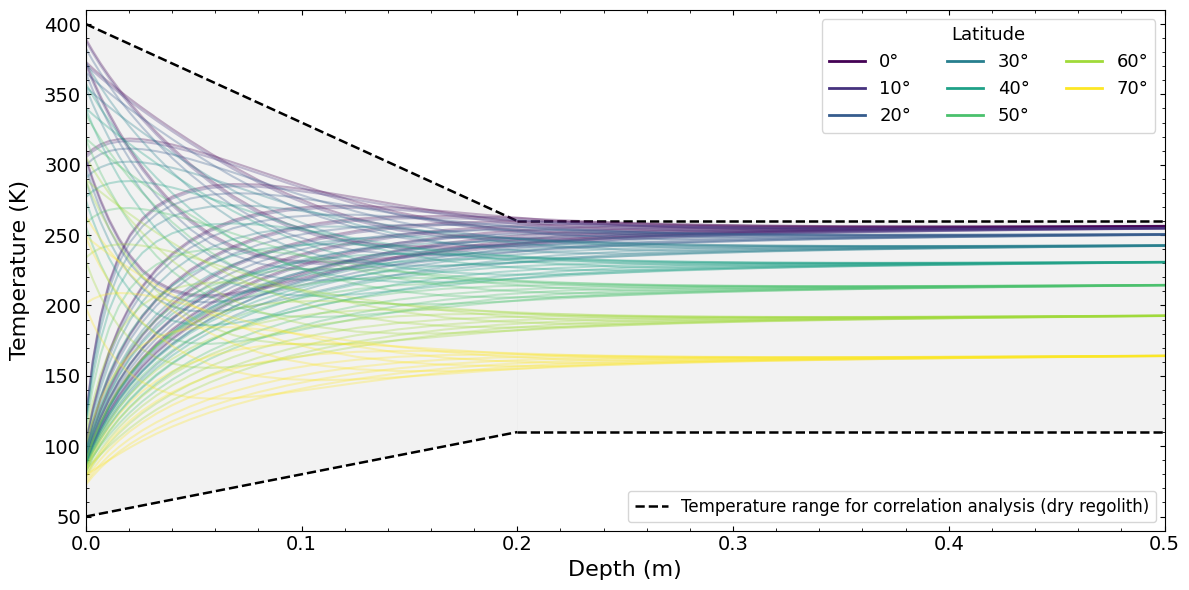

In [12]:
from matplotlib.lines import Line2D


plt.figure(figsize=(12, 6))


# -----------------------------
# TEMPERATURE ENVELOPE USED FOR CORRELATION ANALYSIS
# -----------------------------

z_env = np.array([0, 0.2])
z_env2 = np.array([0.2, 0.5])

T_min_env = np.array([50, 110])
T_max_env = np.array([400, 260])
T_min_env2 = np.array([110, 110])
T_max_env2 = np.array([260, 260])

# Fill between limits
plt.fill_between(
    z_env,
    T_min_env,
    T_max_env,
    color="black",
    alpha=0.05,
    zorder=0,
    edgecolor='none'
)

# Lower and upper boundaries
plt.plot(
    z_env,
    T_min_env,
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1
)

plt.plot(
    z_env,
    T_max_env,
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1
)

plt.fill_between(
    z_env2,
    T_min_env2,
    T_max_env2,
    color="black",
    alpha=0.05,
    zorder=0,
    edgecolor='none'
)

# Lower and upper boundaries
plt.plot(
    z_env2,
    T_min_env2,
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1
)

plt.plot(
    z_env2,
    T_max_env2,
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1
)


# -----------------------------
# TIME SETUP
# -----------------------------

T_period = 24 * 3600
steps_per_day = int(T_period / dt)

if T_period % dt != 0:
    raise ValueError("T_period/dt must be an integer.")


# Local times every 2 hours
desired_hours = np.arange(0, 24, 2)

desired_indices = (
    desired_hours * 3600 / dt
).astype(int)

desired_indices = desired_indices[
    desired_indices < steps_per_day
]


# Color per latitude
colors = plt.cm.viridis(
    np.linspace(0, 1, len(latitude_vector))
)


# Store legend handles
lat_handles = []


# -----------------------------
# LOOP OVER LATITUDES
# -----------------------------

for lat_idx, lat_val in enumerate(latitude_vector):

    T_day = T_profile_lats[lat_idx]


    # Plot profiles for all local times
    for idx_in_day in desired_indices:

        profile = T_day[idx_in_day]

        plt.plot(
            z,
            profile,
            color=colors[lat_idx],
            alpha=0.3,
            zorder=2
        )


    # Noon profile
    noon_idx = int(
        (12 * 3600) / dt
    )

    avg_noon_profile = T_day[noon_idx]


    # Deep temperature used for latitude legend
    T_deep_noon = avg_noon_profile[31]


    # Latitude legend handle
    lat_handles.append(
        Line2D(
            [0],
            [0],
            color=colors[lat_idx],
            lw=2
        )
    )


# -----------------------------
# FORMATTING
# -----------------------------

ax = plt.gca()

plt.xlabel(
    "Depth (m)",
    fontsize=16
)

plt.ylabel(
    "Temperature (K)",
    fontsize=16,
    labelpad=10
)


plt.xlim(
    [0.0, 0.5]
)

plt.ylim(
    [40, 410]
)


plt.yticks(
    np.arange(50, 401, 50),
    fontsize=14
)

plt.xticks(
    np.arange(0, 0.51, 0.1),
    fontsize=14
)


# Minor ticks
ax.set_yticks(
    np.arange(40, 411, 10),
    minor=True
)

ax.set_xticks(
    np.arange(0, 0.51, 0.02),
    minor=True
)


# Tick style
ax.tick_params(
    direction="in"
)

ax.tick_params(
    which="minor",
    direction="in"
)

ax.xaxis.set_ticks_position("both")
ax.yaxis.set_ticks_position("both")


# Put y tick labels on top side (as in your original)
ax.tick_params(
    axis="y",
    labeltop=True,
    labelbottom=False,
    labelsize=14
)


# -----------------------------
# LEGENDS
# -----------------------------

lat_labels = [
    f"{lat}°"
    for lat in latitude_vector
]


legend1 = plt.legend(
    lat_handles,
    lat_labels,
    title="Latitude",
    loc="upper right",
    fontsize=13,
    title_fontsize=13,
    ncols=3,
    frameon=True
)


plt.gca().add_artist(
    legend1
)


# Temperature envelope legend
envelope_handle = Line2D(
    [0],
    [0],
    color="black",
    linestyle="--",
    linewidth=1.8
)


plt.legend(
    [envelope_handle],
    ["Temperature range for correlation analysis (dry regolith)"],
    loc="lower right",
    fontsize=12,
    frameon=True
)


# -----------------------------
# SAVE
# -----------------------------

plt.tight_layout()

plt.savefig(
    os.path.join(
        parent_folder,
        "vertical_all_latitudes_inverted_envelope.pdf"
    ),
    bbox_inches="tight"
)

plt.show()